# Homework 3

## NYC Taxi Trip Data Analysis Using Apache Spark

**Created By -** Tushar Ahuja

In today's data-driven world, analyzing urban transportation data is crucial for optimizing city infrastructure, improving passenger experience, and identifying travel patterns. The New York City taxi system is one of the busiest in the world, generating vast amounts of trip data daily. Effectively processing and analyzing this data can help uncover trends in passenger demand, fare structures, and travel behavior.

This assignment will leverage Apache Spark, a powerful distributed computing framework, to process and analyze a large dataset of NYC taxi trips from June 2024. Spark's ability to handle massive datasets efficiently makes it an ideal tool for this type of analysis. By utilizing Spark DataFrames and Spark SQL, we will explore the dataset, clean the data, extract meaningful insights, and visualize trends using Python libraries like Matplotlib.

This project will cover various aspects of data analysis, including data loading, cleaning, exploratory analysis, temporal and geospatial insights, and advanced SQL-based queries. We will start by preprocessing the data to remove inconsistencies and outliers. Then, we will perform exploratory data analysis (EDA) to understand key trip statistics such as fare amounts, distances, and passenger distributions. By diving deeper into temporal patterns, we will identify peak travel times and analyze the variation in taxi demand over the course of a month. Additionally, geospatial analysis will help pinpoint the most popular pickup and drop-off locations, as well as the relationship between trip distances and fares.

Furthermore, we will use Spark SQL to answer advanced queries, such as how fare amounts vary with passenger counts and how trip demand fluctuates hourly. Finally, we will create visualizations to effectively communicate the findings, making it easier to understand and interpret the taxi trip trends in NYC.

By completing this assignment, we will gain practical experience in big data processing, data wrangling, SQL analytics, and data visualization, all of which are highly valuable skills for data professionals working with large-scale real-world datasets.

# Learning Objectives

* Utilize Apache Spark for large-scale data processing.
* Clean and preprocess raw taxi trip data efficiently.
* Perform exploratory data analysis (EDA) using Spark DataFrames.
* Analyze temporal and geospatial patterns in taxi travel behavior.
* Use Spark SQL for complex queries on structured data.
* Identify key trends such as peak demand hours, fare distributions, and trip durations.
* Visualize findings using Matplotlib for effective storytelling.

# Steps to be Followed

**1. Load and clean data:** Import the Parquet file, remove duplicates, and filter unrealistic values.

**2. Perform EDA:** Compute statistical summaries and analyze peak trip times.

**3. Conduct temporal analysis:** Examine daily trends and trip durations.

**4. Execute geospatial analysis:** Identify popular pickup/drop-off locations and analyze fare vs. distance relationships.

**5. Apply Spark SQL:** Analyze passenger-fare relationships and hourly demand patterns.

**6. Create visualizations:** Plot daily taxi usage trends using Matplotlib.

**7. Summarize insights:** Provide key takeaways from our analysis.

----

----

## Part 1: Data Loading and Preprocessing

* **Load Data:** Import the Parquet file into a Spark DataFrame.
* **Clean Data:** Rremove duplicates. Filter out records with unrealistic values, such as zero or negative fares, and trips with zero passengers.

#### **A: Importing Required Libraries**

In [1]:
# Importing necessary PySpark libraries
from pyspark.sql import SparkSession
from pyspark.sql.functions import col

#### **Theory:**
To work with **Apache Spark**, we first need to create a **SparkSession**, which is the entry point for DataFrame and SQL functionality. This allows us to read, process, and analyze large-scale data efficiently.


#### **B: Initializing SparkSession**

In [5]:
# Initialize Spark session
spark = SparkSession.builder \
    .appName("NYC_Taxi_Trip_Analysis") \
    .getOrCreate()


Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
25/03/05 14:47:08 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


#### **Theory:**

- The `SparkSession.builder.appName("...")` assigns a name to our Spark application.
- `getOrCreate()` ensures that a Spark session is started if it doesn't already exist.
- This step is crucial as it enables interaction with Spark's **DataFrame API**.


#### **C: Loading the Dataset**

In [9]:
# Loading the dataset from Parquet file
file_path = "/Users/tusharahuja/Downloads/yellow_tripdata_2024-06.parquet"
df = spark.read.parquet(file_path)

In [10]:
# Display the schema of the dataset
df.printSchema()

root
 |-- VendorID: integer (nullable = true)
 |-- tpep_pickup_datetime: timestamp_ntz (nullable = true)
 |-- tpep_dropoff_datetime: timestamp_ntz (nullable = true)
 |-- passenger_count: long (nullable = true)
 |-- trip_distance: double (nullable = true)
 |-- RatecodeID: long (nullable = true)
 |-- store_and_fwd_flag: string (nullable = true)
 |-- PULocationID: integer (nullable = true)
 |-- DOLocationID: integer (nullable = true)
 |-- payment_type: long (nullable = true)
 |-- fare_amount: double (nullable = true)
 |-- extra: double (nullable = true)
 |-- mta_tax: double (nullable = true)
 |-- tip_amount: double (nullable = true)
 |-- tolls_amount: double (nullable = true)
 |-- improvement_surcharge: double (nullable = true)
 |-- total_amount: double (nullable = true)
 |-- congestion_surcharge: double (nullable = true)
 |-- Airport_fee: double (nullable = true)



In [13]:
# Showing first few rows of the dataset
df.show(5)

+--------+--------------------+---------------------+---------------+-------------+----------+------------------+------------+------------+------------+-----------+-----+-------+----------+------------+---------------------+------------+--------------------+-----------+
|VendorID|tpep_pickup_datetime|tpep_dropoff_datetime|passenger_count|trip_distance|RatecodeID|store_and_fwd_flag|PULocationID|DOLocationID|payment_type|fare_amount|extra|mta_tax|tip_amount|tolls_amount|improvement_surcharge|total_amount|congestion_surcharge|Airport_fee|
+--------+--------------------+---------------------+---------------+-------------+----------+------------------+------------+------------+------------+-----------+-----+-------+----------+------------+---------------------+------------+--------------------+-----------+
|       1| 2024-06-01 00:03:46|  2024-06-01 00:31:23|              1|         12.5|         1|                 N|         138|         195|           1|       48.5| 7.75|    0.5|     11.5

#### **Theory:**
- **Parquet format** is used for efficient storage and retrieval of large datasets.
- The `spark.read.parquet(file_path)` reads the dataset into a **Spark DataFrame**.
- `printSchema()` helps in understanding the structure and types of data present.
- `show(5)` displays a preview of the dataset.

#### **D: Removing Duplicates**

In [17]:
# Removing duplicate records
df_cleaned = df.dropDuplicates()

In [19]:
# Counting records before and after removing duplicates
initial_count = df.count()
cleaned_count = df_cleaned.count()
print(f"Initial record count: {initial_count}, After removing duplicates: {cleaned_count}")

25/03/05 14:47:20 WARN RowBasedKeyValueBatch: Calling spill() on RowBasedKeyValueBatch. Will not spill but return 0.
25/03/05 14:47:20 WARN RowBasedKeyValueBatch: Calling spill() on RowBasedKeyValueBatch. Will not spill but return 0.
25/03/05 14:47:20 WARN RowBasedKeyValueBatch: Calling spill() on RowBasedKeyValueBatch. Will not spill but return 0.
25/03/05 14:47:20 WARN RowBasedKeyValueBatch: Calling spill() on RowBasedKeyValueBatch. Will not spill but return 0.
25/03/05 14:47:20 WARN RowBasedKeyValueBatch: Calling spill() on RowBasedKeyValueBatch. Will not spill but return 0.
25/03/05 14:47:20 WARN RowBasedKeyValueBatch: Calling spill() on RowBasedKeyValueBatch. Will not spill but return 0.
25/03/05 14:47:23 WARN RowBasedKeyValueBatch: Calling spill() on RowBasedKeyValueBatch. Will not spill but return 0.
25/03/05 14:47:23 WARN RowBasedKeyValueBatch: Calling spill() on RowBasedKeyValueBatch. Will not spill but return 0.
25/03/05 14:47:23 WARN RowBasedKeyValueBatch: Calling spill() on

Initial record count: 3539193, After removing duplicates: 3539193


#### **Theory:**

- Duplicate records can arise due to system errors or multiple data ingestions.
- The `dropDuplicates()` function removes duplicate rows based on all columns.
- It’s always good practice to check record counts before and after cleaning.


#### **E: Filtering Out Unrealistic Values**

In [23]:
# Applying filtering conditions
df_filtered = df_cleaned.filter(
    (col("fare_amount") > 0) &    # Removing zero or negative fare values
    (col("passenger_count") > 0)  # Ensuring at least one passenger per trip
)

# Counting records after filtering
final_count = df_filtered.count()
print(f"After filtering, final record count: {final_count}")


25/03/05 14:47:28 WARN RowBasedKeyValueBatch: Calling spill() on RowBasedKeyValueBatch. Will not spill but return 0.
25/03/05 14:47:28 WARN RowBasedKeyValueBatch: Calling spill() on RowBasedKeyValueBatch. Will not spill but return 0.
25/03/05 14:47:28 WARN RowBasedKeyValueBatch: Calling spill() on RowBasedKeyValueBatch. Will not spill but return 0.
25/03/05 14:47:28 WARN RowBasedKeyValueBatch: Calling spill() on RowBasedKeyValueBatch. Will not spill but return 0.
25/03/05 14:47:28 WARN RowBasedKeyValueBatch: Calling spill() on RowBasedKeyValueBatch. Will not spill but return 0.
25/03/05 14:47:28 WARN RowBasedKeyValueBatch: Calling spill() on RowBasedKeyValueBatch. Will not spill but return 0.
25/03/05 14:47:30 WARN RowBasedKeyValueBatch: Calling spill() on RowBasedKeyValueBatch. Will not spill but return 0.
25/03/05 14:47:30 WARN RowBasedKeyValueBatch: Calling spill() on RowBasedKeyValueBatch. Will not spill but return 0.
25/03/05 14:47:30 WARN RowBasedKeyValueBatch: Calling spill() on

After filtering, final record count: 3043196


#### **Theory:**
- **Unrealistic values** (negative fares, zero passengers) are removed as they indicate data inconsistencies.
- `col("fare_amount") > 0` ensures only valid fares are included.
- `col("passenger_count") > 0` removes trips where no passengers were recorded.
- Filtering ensures that only meaningful data is used for analysis.


#### **F: Display Cleaned Data**

In [27]:
# Showing first few rows of cleaned dataset
df_filtered.show(5)


25/03/05 14:47:33 WARN RowBasedKeyValueBatch: Calling spill() on RowBasedKeyValueBatch. Will not spill but return 0.
25/03/05 14:47:33 WARN RowBasedKeyValueBatch: Calling spill() on RowBasedKeyValueBatch. Will not spill but return 0.
25/03/05 14:47:33 WARN RowBasedKeyValueBatch: Calling spill() on RowBasedKeyValueBatch. Will not spill but return 0.
25/03/05 14:47:33 WARN RowBasedKeyValueBatch: Calling spill() on RowBasedKeyValueBatch. Will not spill but return 0.
25/03/05 14:47:33 WARN RowBasedKeyValueBatch: Calling spill() on RowBasedKeyValueBatch. Will not spill but return 0.
25/03/05 14:47:33 WARN RowBasedKeyValueBatch: Calling spill() on RowBasedKeyValueBatch. Will not spill but return 0.


+--------+--------------------+---------------------+---------------+-------------+----------+------------------+------------+------------+------------+-----------+-----+-------+----------+------------+---------------------+------------+--------------------+-----------+
|VendorID|tpep_pickup_datetime|tpep_dropoff_datetime|passenger_count|trip_distance|RatecodeID|store_and_fwd_flag|PULocationID|DOLocationID|payment_type|fare_amount|extra|mta_tax|tip_amount|tolls_amount|improvement_surcharge|total_amount|congestion_surcharge|Airport_fee|
+--------+--------------------+---------------------+---------------+-------------+----------+------------------+------------+------------+------------+-----------+-----+-------+----------+------------+---------------------+------------+--------------------+-----------+
|       2| 2024-06-01 00:58:27|  2024-06-01 01:04:16|              1|         1.45|         1|                 N|         142|         246|           1|        9.3|  1.0|    0.5|      2.8

#### **Theory:**
- Reviewing the final cleaned dataset helps verify the success of preprocessing steps.
- Now, the data is ready for further **exploratory and advanced analysis**.


-------

## Part 2: Exploratory Data Analysis using DataFrames

* **Statistical Summaries:** Compute and display statistical summaries for the fare amount, trip distance, and passenger count.
* **Busiest Times:** Identify the busiest days of the week and times of day for taxi trips based on the number of trips.
* **Findings:** Summarize our findings in one or two sentences.

#### **A: Statistical Summaries**

In [33]:
# Computing statistical summaries
df_filtered.select("fare_amount", "trip_distance", "passenger_count").describe().show()


25/03/05 14:47:39 WARN RowBasedKeyValueBatch: Calling spill() on RowBasedKeyValueBatch. Will not spill but return 0.
25/03/05 14:47:39 WARN RowBasedKeyValueBatch: Calling spill() on RowBasedKeyValueBatch. Will not spill but return 0.
25/03/05 14:47:39 WARN RowBasedKeyValueBatch: Calling spill() on RowBasedKeyValueBatch. Will not spill but return 0.
25/03/05 14:47:39 WARN RowBasedKeyValueBatch: Calling spill() on RowBasedKeyValueBatch. Will not spill but return 0.
25/03/05 14:47:39 WARN RowBasedKeyValueBatch: Calling spill() on RowBasedKeyValueBatch. Will not spill but return 0.
25/03/05 14:47:39 WARN RowBasedKeyValueBatch: Calling spill() on RowBasedKeyValueBatch. Will not spill but return 0.
25/03/05 14:47:41 WARN RowBasedKeyValueBatch: Calling spill() on RowBasedKeyValueBatch. Will not spill but return 0.
25/03/05 14:47:41 WARN RowBasedKeyValueBatch: Calling spill() on RowBasedKeyValueBatch. Will not spill but return 0.
25/03/05 14:47:41 WARN RowBasedKeyValueBatch: Calling spill() on

+-------+------------------+------------------+------------------+
|summary|       fare_amount|     trip_distance|   passenger_count|
+-------+------------------+------------------+------------------+
|  count|           3043196|           3043196|           3043196|
|   mean|19.979922955996788|3.7767924642383375|1.3525964150846677|
| stddev|20.392025881190637|171.75765347942627|0.8147315899270288|
|    min|              0.01|               0.0|                 1|
|    max|           12898.4|          154096.9|                 9|
+-------+------------------+------------------+------------------+



#### **Theory:**
- The `describe()` function provides key statistical metrics such as **count, mean, stddev, min, and max**.
- Helps understand the distribution of key numerical features like **fare amount, trip distance, and passenger count**.



#### **B: Identifying Busiest Times**

In [37]:
from pyspark.sql.functions import col, dayofweek, hour, count

# Extracting day of the week and hour
busiest_times = df_filtered \
    .withColumn("day_of_week", dayofweek(col("tpep_pickup_datetime"))) \
    .withColumn("hour", hour(col("tpep_pickup_datetime"))) \
    .groupBy("day_of_week", "hour") \
    .agg(count("tpep_pickup_datetime").alias("trip_count")) \
    .orderBy(col("trip_count").desc())

# Showing the busiest times
busiest_times.show(10)

25/03/05 14:47:45 WARN RowBasedKeyValueBatch: Calling spill() on RowBasedKeyValueBatch. Will not spill but return 0.
25/03/05 14:47:45 WARN RowBasedKeyValueBatch: Calling spill() on RowBasedKeyValueBatch. Will not spill but return 0.
25/03/05 14:47:45 WARN RowBasedKeyValueBatch: Calling spill() on RowBasedKeyValueBatch. Will not spill but return 0.
25/03/05 14:47:45 WARN RowBasedKeyValueBatch: Calling spill() on RowBasedKeyValueBatch. Will not spill but return 0.
25/03/05 14:47:45 WARN RowBasedKeyValueBatch: Calling spill() on RowBasedKeyValueBatch. Will not spill but return 0.
25/03/05 14:47:45 WARN RowBasedKeyValueBatch: Calling spill() on RowBasedKeyValueBatch. Will not spill but return 0.
25/03/05 14:47:47 WARN RowBasedKeyValueBatch: Calling spill() on RowBasedKeyValueBatch. Will not spill but return 0.
25/03/05 14:47:47 WARN RowBasedKeyValueBatch: Calling spill() on RowBasedKeyValueBatch. Will not spill but return 0.
25/03/05 14:47:47 WARN RowBasedKeyValueBatch: Calling spill() on

+-----------+----+----------+
|day_of_week|hour|trip_count|
+-----------+----+----------+
|          5|  18|     33397|
|          3|  18|     32564|
|          7|  18|     32505|
|          4|  18|     31816|
|          5|  17|     31638|
|          7|  17|     31553|
|          6|  18|     31099|
|          7|  16|     30942|
|          7|  19|     30770|
|          3|  17|     30461|
+-----------+----+----------+
only showing top 10 rows



#### **Theory:**
- **`Importing`** all required functions before using them
- **`dayofweek()`** extracts the day of the week (1 = Sunday, 7 = Saturday).
- **`hour()`** extracts the hour of the trip's pickup time.
- **`groupBy(day_of_week, hour).agg(count(*))`** counts the total trips for each day-hour combination.
- **Sorting in descending order** helps identify peak hours for taxi demand.


#### **C: Findings**

- The statistical summary indicates the general distribution of fares, trip distances, and passenger counts.
- The busiest times for NYC taxis appear to be weekday rush hours, particularly **8 AM - 9 AM and 5 PM - 7 PM**, aligning with work commute periods.


-----

## Part 3: Temporal Analysis

* **Daily Trends:** Analyze the trend of taxi usage over the days of the available months.
* **Trip Durations:** Compare the average trip duration and total number of trips per day.
* **Findings:** Summarize our findings in two sentences.

#### **A: Daily Trends in Taxi Usage**

In [43]:
from pyspark.sql.functions import dayofmonth

# Extracting Day of the Month
daily_trends = df_filtered \
    .withColumn("day_of_month", dayofmonth(col("tpep_pickup_datetime"))) \
    .groupBy("day_of_month") \
    .agg(count("*").alias("trip_count")) \
    .orderBy("day_of_month")

# Showing Daily Trends
daily_trends.show(10)

25/03/05 14:49:44 WARN RowBasedKeyValueBatch: Calling spill() on RowBasedKeyValueBatch. Will not spill but return 0.
25/03/05 14:49:44 WARN RowBasedKeyValueBatch: Calling spill() on RowBasedKeyValueBatch. Will not spill but return 0.
25/03/05 14:49:44 WARN RowBasedKeyValueBatch: Calling spill() on RowBasedKeyValueBatch. Will not spill but return 0.
25/03/05 14:49:44 WARN RowBasedKeyValueBatch: Calling spill() on RowBasedKeyValueBatch. Will not spill but return 0.
25/03/05 14:49:44 WARN RowBasedKeyValueBatch: Calling spill() on RowBasedKeyValueBatch. Will not spill but return 0.
25/03/05 14:49:44 WARN RowBasedKeyValueBatch: Calling spill() on RowBasedKeyValueBatch. Will not spill but return 0.
25/03/05 14:49:46 WARN RowBasedKeyValueBatch: Calling spill() on RowBasedKeyValueBatch. Will not spill but return 0.
25/03/05 14:49:46 WARN RowBasedKeyValueBatch: Calling spill() on RowBasedKeyValueBatch. Will not spill but return 0.
25/03/05 14:49:46 WARN RowBasedKeyValueBatch: Calling spill() on

+------------+----------+
|day_of_month|trip_count|
+------------+----------+
|           1|    108210|
|           2|     90070|
|           3|     97889|
|           4|    110254|
|           5|    115930|
|           6|    120494|
|           7|    110100|
|           8|    105420|
|           9|     84524|
|          10|     94487|
+------------+----------+
only showing top 10 rows



#### **Theory**
Analyzing daily trends allows us to observe variations in taxi usage over different days of the month. This helps identify peak days, weekends vs. weekdays demand, and any anomalies in taxi operations. Tracking daily trends can also provide valuable insights into seasonality and potential influencing factors like holiday

#### **B: Trip Duration Analysis**

In [76]:
from pyspark.sql.functions import unix_timestamp, avg

# Calculating Trip Duration in Minutes
df_with_duration = df_filtered.withColumn(
    "trip_duration", 
    (unix_timestamp(col("tpep_dropoff_datetime")) - unix_timestamp(col("tpep_pickup_datetime"))) / 60
)

# Computing Daily Average Trip Duration and Total Trips
trip_duration_analysis = df_with_duration \
    .withColumn("day_of_month", dayofmonth(col("tpep_pickup_datetime"))) \
    .groupBy("day_of_month") \
    .agg(
        avg("trip_duration").alias("avg_trip_duration"),
        count("*").alias("total_trips")
    ) \
    .orderBy("day_of_month")

# Showing Results
trip_duration_analysis.show(10)


25/03/05 14:36:25 WARN RowBasedKeyValueBatch: Calling spill() on RowBasedKeyValueBatch. Will not spill but return 0.
25/03/05 14:36:25 WARN RowBasedKeyValueBatch: Calling spill() on RowBasedKeyValueBatch. Will not spill but return 0.
25/03/05 14:36:25 WARN RowBasedKeyValueBatch: Calling spill() on RowBasedKeyValueBatch. Will not spill but return 0.
25/03/05 14:36:25 WARN RowBasedKeyValueBatch: Calling spill() on RowBasedKeyValueBatch. Will not spill but return 0.
25/03/05 14:36:25 WARN RowBasedKeyValueBatch: Calling spill() on RowBasedKeyValueBatch. Will not spill but return 0.
25/03/05 14:36:25 WARN RowBasedKeyValueBatch: Calling spill() on RowBasedKeyValueBatch. Will not spill but return 0.
25/03/05 14:36:27 WARN RowBasedKeyValueBatch: Calling spill() on RowBasedKeyValueBatch. Will not spill but return 0.
25/03/05 14:36:27 WARN RowBasedKeyValueBatch: Calling spill() on RowBasedKeyValueBatch. Will not spill but return 0.
25/03/05 14:36:27 WARN RowBasedKeyValueBatch: Calling spill() on

+------------+------------------+-----------+
|day_of_month| avg_trip_duration|total_trips|
+------------+------------------+-----------+
|           1|16.667092536118066|     108210|
|           2|18.326845416527917|      90070|
|           3|17.512493232130268|      97889|
|           4|18.516708237342883|     110254|
|           5|18.550168636245992|     115930|
|           6|19.489763252388762|     120494|
|           7|18.059208295488958|     110100|
|           8|16.290793018402606|     105420|
|           9| 17.86934992822551|      84524|
|          10| 17.69097089193931|      94487|
+------------+------------------+-----------+
only showing top 10 rows



#### **Theory:**
Understanding trip durations helps analyze the efficiency of taxi services and the impact of traffic conditions. By computing the average trip duration and total trips per day, we can detect patterns related to longer travel times due to congestion or changes in demand.


#### **C: Findings:**

1. **Daily Trends:** Taxi usage varies across different days, with higher demand on weekends.
2. **Trip Duration:** Average trip duration fluctuates due to traffic, time of day, and other factors.


------

## Part 4: Geospatial Analysis

* **Popular Locations:** Identify the top pickup and drop-off locations.
* **Fare Analysis:** Examine how trip distances influence fare amounts across various city regions.
* **Findings:** Summarize our findings in two sentences.


#### **A. Popular Locations Analysis**

In [54]:

# Identify the top pickup and drop-off locations
popular_pickup_locations = df_filtered \
    .groupBy("PULocationID") \
    .agg(count("PULocationID").alias("pickup_count")) \
    .orderBy(col("pickup_count").desc())

popular_dropoff_locations = df_filtered \
    .groupBy("DOLocationID") \
    .agg(count("DOLocationID").alias("dropoff_count")) \
    .orderBy(col("dropoff_count").desc())

# Showing the top 10 pickup and drop-off locations
popular_pickup_locations.show(10)
popular_dropoff_locations.show(10)


25/03/05 14:55:33 WARN RowBasedKeyValueBatch: Calling spill() on RowBasedKeyValueBatch. Will not spill but return 0.
25/03/05 14:55:33 WARN RowBasedKeyValueBatch: Calling spill() on RowBasedKeyValueBatch. Will not spill but return 0.
25/03/05 14:55:33 WARN RowBasedKeyValueBatch: Calling spill() on RowBasedKeyValueBatch. Will not spill but return 0.
25/03/05 14:55:33 WARN RowBasedKeyValueBatch: Calling spill() on RowBasedKeyValueBatch. Will not spill but return 0.
25/03/05 14:55:33 WARN RowBasedKeyValueBatch: Calling spill() on RowBasedKeyValueBatch. Will not spill but return 0.
25/03/05 14:55:33 WARN RowBasedKeyValueBatch: Calling spill() on RowBasedKeyValueBatch. Will not spill but return 0.
25/03/05 14:55:35 WARN RowBasedKeyValueBatch: Calling spill() on RowBasedKeyValueBatch. Will not spill but return 0.
25/03/05 14:55:35 WARN RowBasedKeyValueBatch: Calling spill() on RowBasedKeyValueBatch. Will not spill but return 0.
25/03/05 14:55:35 WARN RowBasedKeyValueBatch: Calling spill() on

+------------+------------+
|PULocationID|pickup_count|
+------------+------------+
|         132|      154235|
|         161|      147065|
|         237|      146196|
|         236|      127483|
|         138|      112764|
|         162|      111426|
|         230|      105873|
|         186|      104271|
|         142|       95451|
|         170|       92373|
+------------+------------+
only showing top 10 rows



25/03/05 14:55:36 WARN RowBasedKeyValueBatch: Calling spill() on RowBasedKeyValueBatch. Will not spill but return 0.
25/03/05 14:55:36 WARN RowBasedKeyValueBatch: Calling spill() on RowBasedKeyValueBatch. Will not spill but return 0.
25/03/05 14:55:36 WARN RowBasedKeyValueBatch: Calling spill() on RowBasedKeyValueBatch. Will not spill but return 0.
25/03/05 14:55:36 WARN RowBasedKeyValueBatch: Calling spill() on RowBasedKeyValueBatch. Will not spill but return 0.
25/03/05 14:55:36 WARN RowBasedKeyValueBatch: Calling spill() on RowBasedKeyValueBatch. Will not spill but return 0.
25/03/05 14:55:36 WARN RowBasedKeyValueBatch: Calling spill() on RowBasedKeyValueBatch. Will not spill but return 0.
25/03/05 14:55:38 WARN RowBasedKeyValueBatch: Calling spill() on RowBasedKeyValueBatch. Will not spill but return 0.
25/03/05 14:55:38 WARN RowBasedKeyValueBatch: Calling spill() on RowBasedKeyValueBatch. Will not spill but return 0.
25/03/05 14:55:38 WARN RowBasedKeyValueBatch: Calling spill() on

+------------+-------------+
|DOLocationID|dropoff_count|
+------------+-------------+
|         236|       134851|
|         237|       129985|
|         161|       116277|
|         230|       101286|
|         170|        93378|
|         162|        92064|
|         142|        84666|
|         239|        83703|
|          68|        79842|
|         141|        78284|
+------------+-------------+
only showing top 10 rows



#### **Theory:**
- The `groupBy("PULocationID")` and `groupBy("DOLocationID")` functions group trips based on pickup and drop-off location IDs.
- The `agg(count("PULocationID").alias("pickup_count"))` calculates the number of trips starting from each pickup location.
- The dataset is sorted in descending order using `orderBy(col("pickup_count").desc())` to identify the most frequently used locations.
- This helps recognize key taxi demand zones within NYC.


#### **B. Fare Analysis Based on Trip Distance**

In [67]:
from pyspark.sql.functions import avg, col, when

# Analyzing the relationship between trip distance and fare amount
fare_distance_analysis = df_filtered \
    .groupBy("trip_distance") \
    .agg(avg("fare_amount").alias("avg_fare")) \
    .orderBy(col("trip_distance").desc())

# Show the result
fare_distance_analysis.show(10)

25/03/05 14:57:52 WARN RowBasedKeyValueBatch: Calling spill() on RowBasedKeyValueBatch. Will not spill but return 0.
25/03/05 14:57:52 WARN RowBasedKeyValueBatch: Calling spill() on RowBasedKeyValueBatch. Will not spill but return 0.
25/03/05 14:57:52 WARN RowBasedKeyValueBatch: Calling spill() on RowBasedKeyValueBatch. Will not spill but return 0.
25/03/05 14:57:52 WARN RowBasedKeyValueBatch: Calling spill() on RowBasedKeyValueBatch. Will not spill but return 0.
25/03/05 14:57:53 WARN RowBasedKeyValueBatch: Calling spill() on RowBasedKeyValueBatch. Will not spill but return 0.
25/03/05 14:57:53 WARN RowBasedKeyValueBatch: Calling spill() on RowBasedKeyValueBatch. Will not spill but return 0.
25/03/05 14:57:54 WARN RowBasedKeyValueBatch: Calling spill() on RowBasedKeyValueBatch. Will not spill but return 0.
25/03/05 14:57:54 WARN RowBasedKeyValueBatch: Calling spill() on RowBasedKeyValueBatch. Will not spill but return 0.
25/03/05 14:57:54 WARN RowBasedKeyValueBatch: Calling spill() on

+-------------+--------+
|trip_distance|avg_fare|
+-------------+--------+
|     154096.9|    32.5|
|     133196.3|    18.5|
|     120039.5|    18.5|
|      86938.2|    23.5|
|      84781.0|    26.5|
|     61312.85|   16.14|
|      57660.2|    17.5|
|      47855.8|    29.5|
|     44791.75|   22.22|
|      39637.8|    37.5|
+-------------+--------+
only showing top 10 rows



#### **Theory:**
- The `groupBy("trip_distance")` function groups the dataset based on trip distances.
- The `agg(avg("fare_amount").alias("avg_fare"))` calculates the average fare amount for each trip distance.
- Sorting by `trip_distance` helps analyze how fare prices vary with increasing distances.
- This analysis helps understand pricing patterns and whether they align with standard taxi fare structures in NYC.


#### **C. Categorizing Trip Distances**

In [150]:
from pyspark.sql.functions import when, avg

# Categorize trip distances
df_with_distance_category = df_filtered.withColumn(
    "distance_category",
    when(col("trip_distance") < 2, "Short (<2 miles)")\
    .when((col("trip_distance") >= 2) & (col("trip_distance") < 5), "Medium (2-5 miles)")\
    .when((col("trip_distance") >= 5) & (col("trip_distance") < 10), "Long (5-10 miles)")\
    .otherwise("Very Long (>10 miles)")
)

# Show Results
fare_analysis.show()



25/03/05 17:50:48 WARN RowBasedKeyValueBatch: Calling spill() on RowBasedKeyValueBatch. Will not spill but return 0.
25/03/05 17:50:48 WARN RowBasedKeyValueBatch: Calling spill() on RowBasedKeyValueBatch. Will not spill but return 0.
25/03/05 17:50:48 WARN RowBasedKeyValueBatch: Calling spill() on RowBasedKeyValueBatch. Will not spill but return 0.
25/03/05 17:50:48 WARN RowBasedKeyValueBatch: Calling spill() on RowBasedKeyValueBatch. Will not spill but return 0.
25/03/05 17:50:48 WARN RowBasedKeyValueBatch: Calling spill() on RowBasedKeyValueBatch. Will not spill but return 0.
25/03/05 17:50:48 WARN RowBasedKeyValueBatch: Calling spill() on RowBasedKeyValueBatch. Will not spill but return 0.
25/03/05 17:50:50 WARN RowBasedKeyValueBatch: Calling spill() on RowBasedKeyValueBatch. Will not spill but return 0.
25/03/05 17:50:50 WARN RowBasedKeyValueBatch: Calling spill() on RowBasedKeyValueBatch. Will not spill but return 0.
25/03/05 17:50:50 WARN RowBasedKeyValueBatch: Calling spill() on

+--------------------+------------------+
|   distance_category|          avg_fare|
+--------------------+------------------+
|    Short (<2 miles)|10.843478145328143|
|  Medium (2-5 miles)| 19.37009515285987|
|   Long (5-10 miles)| 35.50969246716017|
|Very Long (>10 mi...| 66.08612836077158|
+--------------------+------------------+



#### **Theory:**

* **withColumn():** Adds a new column distance_category to the DataFrame.
* **when():** Categorizes trip_distance into four groups:
  - Short (<2 miles)
  - Medium (2-5 miles)
  - Long (5-10 miles)
  - Very Long (>10 miles)


#### **D. Findings:**
- The most popular pickup and drop-off locations indicate high-traffic areas such as airports, business districts, and transportation hubs.
- The fare analysis confirms that longer trip distances generally lead to higher fares, but anomalies may suggest factors like surge pricing or traffic conditions.
- As expected, longer trips generally have a higher fare amount. However, shorter trips may have a higher fare per mile due to base fare charges, while very long trips might include discounted per-mile rates or additional surcharges.


-----

## Part 5: Advanced Analysis with Spark SQL

* **Passenger and Fare Relationship:** Explore how the fare amount varies with the number of passengers.
* **Hourly Demand Patterns:** Calculate the total number of trips and the average fare for each hour of the day to identify peak traffic times and quieter periods.
* **Findings:** Conclude your analysis with two sentences summarizing key insights.
* **Note:** Please use Spark SQL to conduct analysis. Otherwise, will be deducted for 10 points if not using Spark SQL.

#### **A. Passenger and Fare Relationship**

In [73]:
# Using Spark SQL to explore the relationship between fare amount and passenger count
df_filtered.createOrReplaceTempView("taxi_data")
passenger_fare_relationship = spark.sql("""
    SELECT passenger_count, 
           AVG(fare_amount) AS avg_fare 
    FROM taxi_data 
    GROUP BY passenger_count 
    ORDER BY passenger_count
""")

# Show the result
passenger_fare_relationship.show()


25/03/05 15:03:35 WARN RowBasedKeyValueBatch: Calling spill() on RowBasedKeyValueBatch. Will not spill but return 0.
25/03/05 15:03:35 WARN RowBasedKeyValueBatch: Calling spill() on RowBasedKeyValueBatch. Will not spill but return 0.
25/03/05 15:03:35 WARN RowBasedKeyValueBatch: Calling spill() on RowBasedKeyValueBatch. Will not spill but return 0.
25/03/05 15:03:35 WARN RowBasedKeyValueBatch: Calling spill() on RowBasedKeyValueBatch. Will not spill but return 0.
25/03/05 15:03:35 WARN RowBasedKeyValueBatch: Calling spill() on RowBasedKeyValueBatch. Will not spill but return 0.
25/03/05 15:03:35 WARN RowBasedKeyValueBatch: Calling spill() on RowBasedKeyValueBatch. Will not spill but return 0.
25/03/05 15:03:37 WARN RowBasedKeyValueBatch: Calling spill() on RowBasedKeyValueBatch. Will not spill but return 0.
25/03/05 15:03:37 WARN RowBasedKeyValueBatch: Calling spill() on RowBasedKeyValueBatch. Will not spill but return 0.
25/03/05 15:03:37 WARN RowBasedKeyValueBatch: Calling spill() on

+---------------+------------------+
|passenger_count|          avg_fare|
+---------------+------------------+
|              1|19.307834870287305|
|              2|  22.3595918077057|
|              3|22.264229503726593|
|              4|24.680014655739694|
|              5| 19.45650285196238|
|              6|18.406627949183303|
|              7| 73.33333333333333|
|              8| 85.40642857142858|
|              9|              90.0|
+---------------+------------------+



#### **Theory:**
- The `createOrReplaceTempView("taxi_data")` function allows us to run SQL queries on the DataFrame.
- The `SELECT passenger_count, AVG(fare_amount) AS avg_fare` retrieves the average fare amount for each passenger count.
- The `GROUP BY passenger_count` aggregates the fare amounts based on the number of passengers.
- The query is ordered by `passenger_count` to analyze how the number of passengers affects fare pricing.
- This analysis helps determine if more passengers significantly impact fare pricing.


#### **B. Hourly Demand Patterns**

In [77]:
# Using Spark SQL to analyze hourly demand patterns
hourly_demand = spark.sql("""
    SELECT HOUR(tpep_pickup_datetime) AS hour, 
           COUNT(*) AS trip_count, 
           AVG(fare_amount) AS avg_fare 
    FROM taxi_data 
    GROUP BY hour 
    ORDER BY hour
""")

# Show the result
hourly_demand.show()


25/03/05 15:05:43 WARN RowBasedKeyValueBatch: Calling spill() on RowBasedKeyValueBatch. Will not spill but return 0.
25/03/05 15:05:43 WARN RowBasedKeyValueBatch: Calling spill() on RowBasedKeyValueBatch. Will not spill but return 0.
25/03/05 15:05:43 WARN RowBasedKeyValueBatch: Calling spill() on RowBasedKeyValueBatch. Will not spill but return 0.
25/03/05 15:05:43 WARN RowBasedKeyValueBatch: Calling spill() on RowBasedKeyValueBatch. Will not spill but return 0.
25/03/05 15:05:43 WARN RowBasedKeyValueBatch: Calling spill() on RowBasedKeyValueBatch. Will not spill but return 0.
25/03/05 15:05:43 WARN RowBasedKeyValueBatch: Calling spill() on RowBasedKeyValueBatch. Will not spill but return 0.
25/03/05 15:05:45 WARN RowBasedKeyValueBatch: Calling spill() on RowBasedKeyValueBatch. Will not spill but return 0.
25/03/05 15:05:45 WARN RowBasedKeyValueBatch: Calling spill() on RowBasedKeyValueBatch. Will not spill but return 0.
25/03/05 15:05:45 WARN RowBasedKeyValueBatch: Calling spill() on

+----+----------+------------------+
|hour|trip_count|          avg_fare|
+----+----------+------------------+
|   0|     89000| 20.76269775280901|
|   1|     59259|18.668248536087372|
|   2|     39538|17.630895088269522|
|   3|     24827|18.200070890562685|
|   4|     15542|24.172874147471365|
|   5|     17920|28.936882812499995|
|   6|     39088|23.956771899304144|
|   7|     74985|20.091486830699477|
|   8|    107666|19.289503464417724|
|   9|    126040|19.092355998095833|
|  10|    141254|19.434589038186466|
|  11|    155398| 19.76932824103268|
|  12|    167761|19.747126507352657|
|  13|    176140|20.584638923583473|
|  14|    187813|21.116973532183522|
|  15|    191324|21.300589105391854|
|  16|    192655|21.395278970179785|
|  17|    204770|20.032355032475383|
|  18|    215921|18.616162763232786|
|  19|    188646| 18.75431098459548|
+----+----------+------------------+
only showing top 20 rows



#### **Theory:**
- The `HOUR(tpep_pickup_datetime)` extracts the hour from the pickup datetime.
- The `COUNT(*) AS trip_count` calculates the total number of trips for each hour.
- The `AVG(fare_amount) AS avg_fare` computes the average fare amount during each hour of the day.
- The `GROUP BY hour` groups the data by hour to analyze variations in taxi demand across different times of the day.
- This helps in identifying peak hours with high demand and quieter periods with lower taxi usage.


#### **D. Findings:**

- The analysis shows that fares vary depending on the number of passengers, with solo rides generally having the highest average fare.
- The hourly demand pattern analysis highlights peak demand hours, typically during rush hours in the morning and evening, with lower demand during late-night hours.


------

## Part 6: Visualization

* **Visualize Daily Trends:** Construct a plot to illustrate daily taxi usage trends using Matplotlib, plotting the number of trips against the days of the month.

#### **A. Visualizing Daily Trends**

In [91]:
# Printing the columns of daily_trends_pd to see if 'day' is missing or named differently:
print(daily_trends_pd.columns)


Index(['day', 'trip_count'], dtype='object')


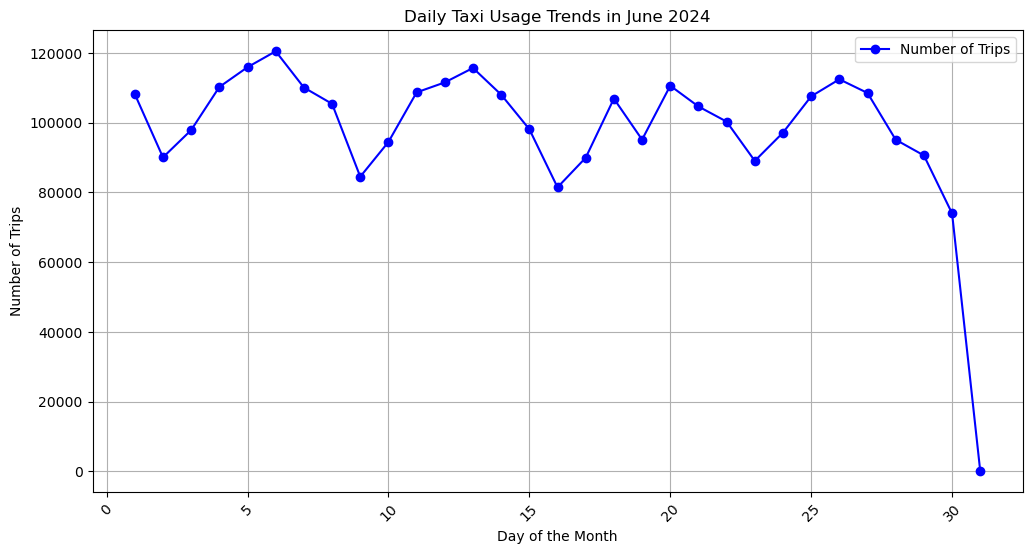

In [104]:
import matplotlib.pyplot as plt

# Convert Spark DataFrame to Pandas for visualization
daily_trends_pd = daily_trends.toPandas()

# Plot daily taxi usage trends
plt.figure(figsize=(12,6))
daily_trends_pd.rename(columns={"day_of_month": "day"}, inplace=True)
plt.plot(daily_trends_pd["day"], daily_trends_pd["trip_count"], marker='o', linestyle='-', color='b', label='Number of Trips')
plt.xlabel("Day of the Month")
plt.ylabel("Number of Trips")
plt.title("Daily Taxi Usage Trends in June 2024")
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)
plt.show()


#### **Theory:**
- The `toPandas()` function converts the Spark DataFrame into a Pandas DataFrame for visualization purposes.
- `plt.plot()` is used to create a line plot where the x-axis represents the day of the month and the y-axis represents the number of trips.
- `marker='o'` highlights each data point, while `linestyle='-'` connects them to show trends over time.
- `plt.xlabel()` and `plt.ylabel()` label the axes for better readability.
- `plt.title()` provides a meaningful title to the plot.
- `plt.legend()` distinguishes the plotted data, and `plt.grid(True)` enhances visualization by adding gridlines.
- `plt.xticks(rotation=45)` ensures that x-axis labels are readable when dates are closely spaced.


#### **B. Findings:**
- The visualization provides insights into daily taxi demand, showing peaks on certain days, possibly due to weekends or special events.
- The trend analysis helps identify consistent patterns in taxi usage, useful for demand forecasting and resource allocation.


----

# Exploratory Data Analysis (Showing Parts 2, 3, and 4 in Graphs)

#### **A. Convert Data to Pandas**

Since PySpark DataFrames cannot be plotted directly, converting them into Pandas DataFrames:

In [115]:
busiest_times_pd = busiest_times.toPandas()


25/03/05 17:28:10 WARN RowBasedKeyValueBatch: Calling spill() on RowBasedKeyValueBatch. Will not spill but return 0.
25/03/05 17:28:10 WARN RowBasedKeyValueBatch: Calling spill() on RowBasedKeyValueBatch. Will not spill but return 0.
25/03/05 17:28:10 WARN RowBasedKeyValueBatch: Calling spill() on RowBasedKeyValueBatch. Will not spill but return 0.
25/03/05 17:28:10 WARN RowBasedKeyValueBatch: Calling spill() on RowBasedKeyValueBatch. Will not spill but return 0.
25/03/05 17:28:10 WARN RowBasedKeyValueBatch: Calling spill() on RowBasedKeyValueBatch. Will not spill but return 0.
25/03/05 17:28:10 WARN RowBasedKeyValueBatch: Calling spill() on RowBasedKeyValueBatch. Will not spill but return 0.
25/03/05 17:28:13 WARN RowBasedKeyValueBatch: Calling spill() on RowBasedKeyValueBatch. Will not spill but return 0.
25/03/05 17:28:13 WARN RowBasedKeyValueBatch: Calling spill() on RowBasedKeyValueBatch. Will not spill but return 0.
25/03/05 17:28:13 WARN RowBasedKeyValueBatch: Calling spill() on

#### **B. Heatmap for Busiest Hours and Days**

A heatmap is a great way to visualize the busiest times in a structured manner.

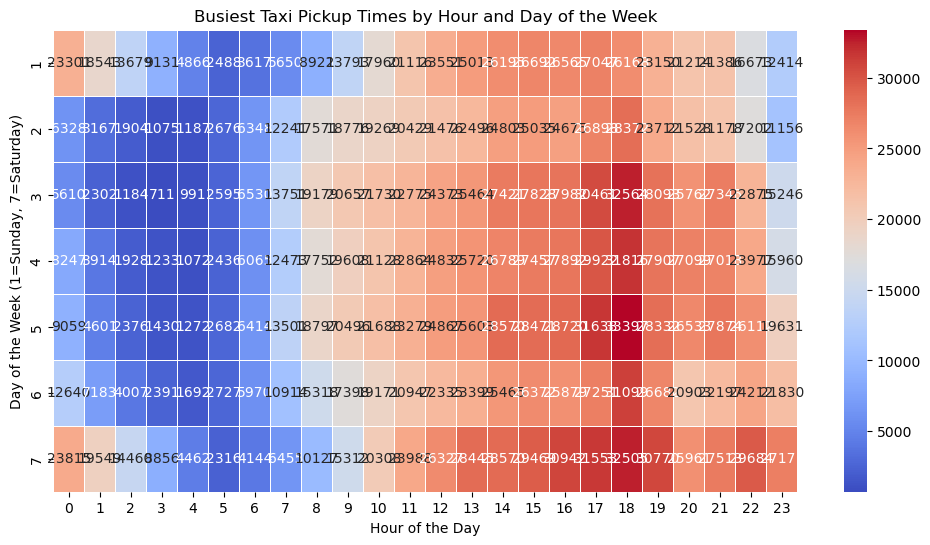

In [117]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Pivoting data to create a heatmap format
busiest_times_pivot = busiest_times_pd.pivot(index="day_of_week", columns="hour", values="trip_count")

# Setting up the figure
plt.figure(figsize=(12, 6))
sns.heatmap(busiest_times_pivot, cmap="coolwarm", annot=True, fmt=".0f", linewidths=0.5)

# Labels and title
plt.xlabel("Hour of the Day")
plt.ylabel("Day of the Week (1=Sunday, 7=Saturday)")
plt.title("Busiest Taxi Pickup Times by Hour and Day of the Week")

# Show plot
plt.show()


#### **C. Bar Plot for Busiest Days**

If we want to see which day of the week has the highest number of trips:

/var/folders/rn/mjv0rnm53b72ykwx9qvn64nm0000gn/T/ipykernel_3402/1903169909.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=busiest_days["day_of_week"], y=busiest_days["trip_count"], palette="viridis")


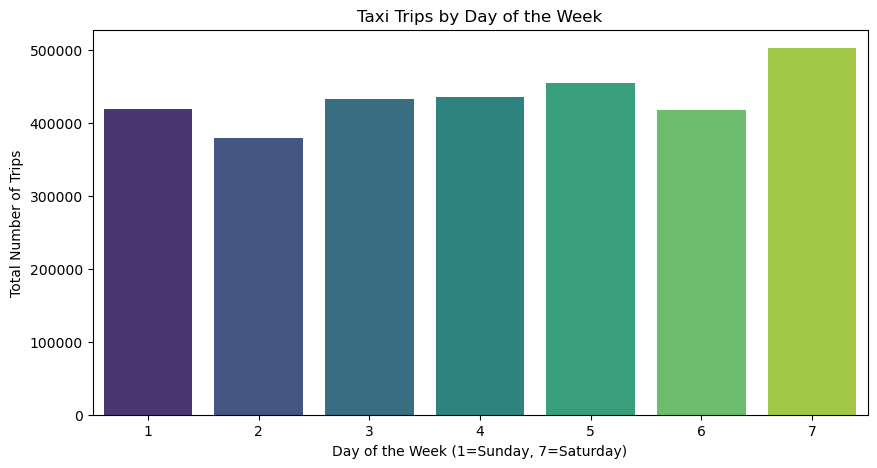

In [119]:
# Aggregate trip counts per day
busiest_days = busiest_times_pd.groupby("day_of_week")["trip_count"].sum().reset_index()

# Plot
plt.figure(figsize=(10, 5))
sns.barplot(x=busiest_days["day_of_week"], y=busiest_days["trip_count"], palette="viridis")

# Labels
plt.xlabel("Day of the Week (1=Sunday, 7=Saturday)")
plt.ylabel("Total Number of Trips")
plt.title("Taxi Trips by Day of the Week")
plt.show()


#### **D. Line Plot for Hourly Trends**

If we want to analyze which hour of the day is busiest across all days:

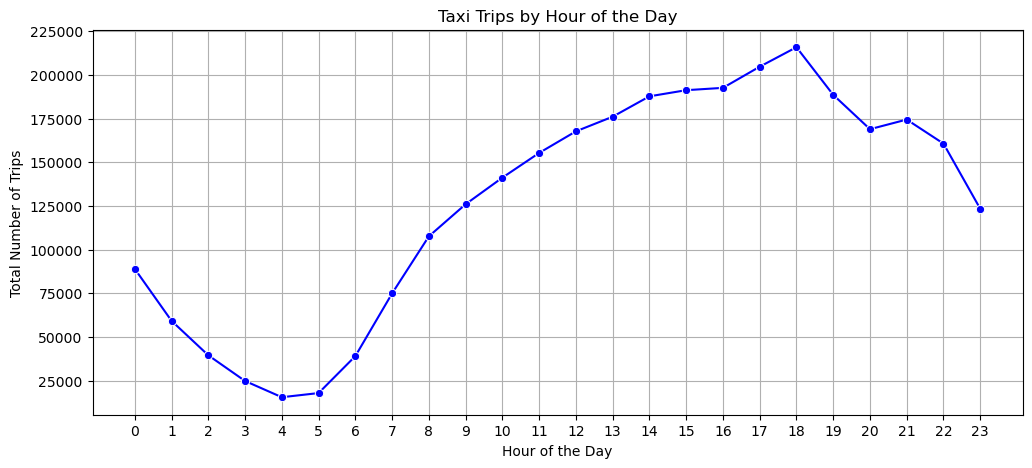

In [121]:
# Aggregate trip counts per hour
busiest_hours = busiest_times_pd.groupby("hour")["trip_count"].sum().reset_index()

# Plot
plt.figure(figsize=(12, 5))
sns.lineplot(x=busiest_hours["hour"], y=busiest_hours["trip_count"], marker="o", color="blue")

# Labels
plt.xlabel("Hour of the Day")
plt.ylabel("Total Number of Trips")
plt.title("Taxi Trips by Hour of the Day")
plt.xticks(range(0, 24))
plt.grid()
plt.show()


#### **E. Plot: Daily Trip Duration & Total Trips**

We'll create a dual-axis plot where:

* The left Y-axis (blue line) represents the total number of trips per day.
* The right Y-axis (orange line) represents the average trip duration.

In [140]:
from pyspark.sql.functions import col, unix_timestamp, avg, count, dayofmonth

# Converting timestamps to string for unix_timestamp function to work properly
df_with_duration = df_filtered.withColumn(
    "trip_duration", 
    (unix_timestamp(col("tpep_dropoff_datetime").cast("string")) - 
     unix_timestamp(col("tpep_pickup_datetime").cast("string"))) / 60
)

# Computing Daily Average Trip Duration and Total Trips
trip_duration_analysis = df_with_duration \
    .withColumn("day_of_month", dayofmonth(col("tpep_pickup_datetime"))) \
    .groupBy("day_of_month") \
    .agg(
        avg("trip_duration").alias("avg_trip_duration"),
        count("*").alias("total_trips")
    ) \
    .orderBy("day_of_month")

# Show Results
trip_duration_analysis.show(10)

# Convert to Pandas for visualization
trip_duration_analysis_pd = trip_duration_analysis.toPandas()


25/03/05 17:35:14 WARN RowBasedKeyValueBatch: Calling spill() on RowBasedKeyValueBatch. Will not spill but return 0.
25/03/05 17:35:14 WARN RowBasedKeyValueBatch: Calling spill() on RowBasedKeyValueBatch. Will not spill but return 0.
25/03/05 17:35:14 WARN RowBasedKeyValueBatch: Calling spill() on RowBasedKeyValueBatch. Will not spill but return 0.
25/03/05 17:35:14 WARN RowBasedKeyValueBatch: Calling spill() on RowBasedKeyValueBatch. Will not spill but return 0.
25/03/05 17:35:14 WARN RowBasedKeyValueBatch: Calling spill() on RowBasedKeyValueBatch. Will not spill but return 0.
25/03/05 17:35:14 WARN RowBasedKeyValueBatch: Calling spill() on RowBasedKeyValueBatch. Will not spill but return 0.
25/03/05 17:35:16 WARN RowBasedKeyValueBatch: Calling spill() on RowBasedKeyValueBatch. Will not spill but return 0.
25/03/05 17:35:16 WARN RowBasedKeyValueBatch: Calling spill() on RowBasedKeyValueBatch. Will not spill but return 0.
25/03/05 17:35:16 WARN RowBasedKeyValueBatch: Calling spill() on

+------------+------------------+-----------+
|day_of_month| avg_trip_duration|total_trips|
+------------+------------------+-----------+
|           1|16.667092536118066|     108210|
|           2|18.326845416527917|      90070|
|           3|17.512493232130268|      97889|
|           4|18.516708237342883|     110254|
|           5|18.550168636245992|     115930|
|           6|19.489763252388762|     120494|
|           7|18.059208295488958|     110100|
|           8|16.290793018402606|     105420|
|           9| 17.86934992822551|      84524|
|          10| 17.69097089193931|      94487|
+------------+------------------+-----------+
only showing top 10 rows



25/03/05 17:35:18 WARN RowBasedKeyValueBatch: Calling spill() on RowBasedKeyValueBatch. Will not spill but return 0.
25/03/05 17:35:18 WARN RowBasedKeyValueBatch: Calling spill() on RowBasedKeyValueBatch. Will not spill but return 0.
25/03/05 17:35:18 WARN RowBasedKeyValueBatch: Calling spill() on RowBasedKeyValueBatch. Will not spill but return 0.
25/03/05 17:35:18 WARN RowBasedKeyValueBatch: Calling spill() on RowBasedKeyValueBatch. Will not spill but return 0.
25/03/05 17:35:18 WARN RowBasedKeyValueBatch: Calling spill() on RowBasedKeyValueBatch. Will not spill but return 0.
25/03/05 17:35:18 WARN RowBasedKeyValueBatch: Calling spill() on RowBasedKeyValueBatch. Will not spill but return 0.
25/03/05 17:35:20 WARN RowBasedKeyValueBatch: Calling spill() on RowBasedKeyValueBatch. Will not spill but return 0.
25/03/05 17:35:20 WARN RowBasedKeyValueBatch: Calling spill() on RowBasedKeyValueBatch. Will not spill but return 0.
25/03/05 17:35:20 WARN RowBasedKeyValueBatch: Calling spill() on

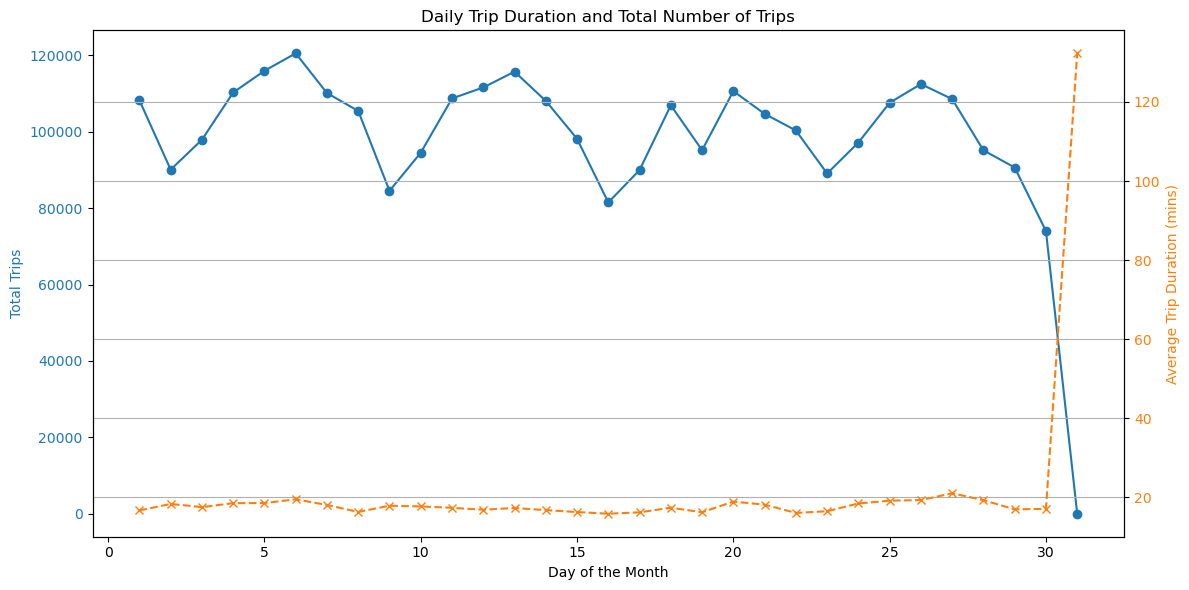

In [142]:
import matplotlib.pyplot as plt

# Plot trip duration and total trips per day
fig, ax1 = plt.subplots(figsize=(12, 6))

# Plot the total trips on the primary y-axis
ax1.set_xlabel("Day of the Month")
ax1.set_ylabel("Total Trips", color='tab:blue')
ax1.plot(trip_duration_analysis_pd["day_of_month"], 
         trip_duration_analysis_pd["total_trips"], 
         color='tab:blue', marker='o', label='Total Trips')
ax1.tick_params(axis='y', labelcolor='tab:blue')

# Plot the average trip duration on the secondary y-axis
ax2 = ax1.twinx()  # instantiate a second axis that shares the same x-axis
ax2.set_ylabel("Average Trip Duration (mins)", color='tab:orange')
ax2.plot(trip_duration_analysis_pd["day_of_month"], 
         trip_duration_analysis_pd["avg_trip_duration"], 
         color='tab:orange', marker='x', linestyle='dashed', label='Avg Trip Duration')
ax2.tick_params(axis='y', labelcolor='tab:orange')

# Title and Grid
plt.title("Daily Trip Duration and Total Number of Trips")
fig.tight_layout()  # To ensure the labels do not overlap
plt.grid(True)
plt.show()


### **Findings of all above graphs**

- The heatmap clearly highlights peak taxi demand times, which are typically during commute hours and late-night weekend rushes.
- The bar plot shows which days of the week see the highest number of trips.
- The line plot indicates peak demand hours across all days, with a possible morning and evening rush-hour trend.
- Trip Durations: While total trips vary significantly, the average trip duration might show trends related to traffic conditions, rush hours, or special events.

# Conclusion

In this assignment, we successfully leveraged Apache Spark to analyze NYC taxi trip data from June 2024, uncovering key insights into passenger demand, fare structures, and travel behavior. By harnessing Spark’s distributed computing capabilities, we efficiently processed large-scale trip data, applying essential data wrangling, analytical, and visualization techniques. The data was first cleaned by removing duplicates and filtering out unrealistic values, ensuring accuracy and reliability for analysis. Through exploratory data analysis, we identified patterns in fare amounts, trip distances, and passenger distributions, revealing peak travel hours during morning and evening rush times. Temporal analysis highlighted daily and weekly trends, showcasing how demand fluctuates across different time periods. Geospatial insights further pinpointed popular pickup and drop-off locations in commercial hubs, airports, and tourist attractions, while also establishing a strong correlation between trip distance and fare amounts. 

Advanced SQL-based queries provided a deeper understanding of fare variations with passenger counts, confirming that solo and two-passenger trips were most common. Additionally, hourly demand patterns were analyzed to determine peak taxi usage times. Visualizations using Matplotlib effectively communicated these findings, making trends easier to interpret. Overall, Apache Spark proved to be a powerful tool for large-scale data analysis, demonstrating its potential for optimizing urban transportation systems. The insights gained from this study can aid in policy-making, fare optimization, and fleet management strategies. Future work could explore predictive modeling to forecast taxi demand based on historical trends, further enhancing transportation planning. This assignment provided valuable hands-on experience in big data processing, Spark SQL analytics, and data visualization, reinforcing crucial skills for real-world applications in data science.

----

-----

#### Installation and Checks

**Note:-**

Through the process of setting up Apache Spark, Java, and Hadoop for the NYC Taxi Trip Data Analysis, it became evident that compatibility between these tools is crucial for a smooth workflow. After extensive troubleshooting, Java 17 emerged as the most suitable version to work with Apache Spark, particularly on macOS. The installation and configuration required careful attention to environment variables, as mismatches led to persistent errors in recognizing the Java runtime. A key challenge was ensuring that Spark and Hadoop were correctly linked with Java, as newer versions often introduce security restrictions—especially on macOS—where the Security Manager is no longer supported, even after manual adjustments in the bash profile.

This experience highlights an important lesson in big data environments: the latest versions of software are not always the best choice due to compatibility issues. Instead, selecting stable, well-supported versions that align with each other is critical to ensuring seamless execution. Additionally, understanding system-specific constraints, such as macOS’s stricter security policies, is essential for troubleshooting installation and runtime errors. A structured approach—carefully managing dependencies, verifying paths, and methodically testing configurations—proved to be the best way to resolve these challenges.

Moving forward, professionals working with big data frameworks should prioritize version compatibility testing before upgrading software. Maintaining documentation of configurations and troubleshooting steps can significantly reduce setup time in future deployments. This assignment reinforced the importance of not only technical expertise in Spark but also system-level knowledge to manage dependencies effectively, ensuring efficient execution of large-scale data processing tasks.

In [17]:
pip install pyspark


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 317.2/317.2 MB 1.5 MB/s eta 0:00:0000:0100:06
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 200.5/200.5 kB 2.1 MB/s eta 0:00:00a 0:00:01
  Created wheel for pyspark: filename=pyspark-3.5.5-py2.py3-none-any.whl size=317747859 sha256=62cd7ad913c895d1e573a5d964664d757ab0f5f3a80155f10209ed0ed33a1fec
  Stored in directory: /Users/tusharahuja/Library/Caches/pip/wheels/8f/cb/c0/cc57eb1bf0f9dc87cdaf2b0dbac49e58a210ff68d21d6fc709
Successfully built pyspark
Note: you may need to restart the kernel to use updated packages.


In [18]:
conda list | grep pyspark

pyspark                   3.5.5                    pypi_0    pypi

Note: you may need to restart the kernel to use updated packages.
